In [2]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier 

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


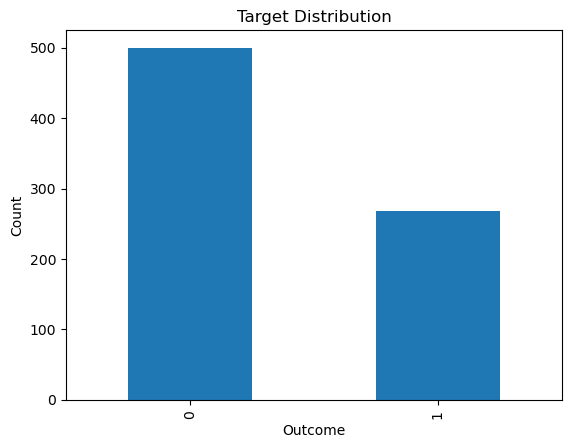

In [7]:
df["Outcome"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

In [8]:
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

In [9]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [10]:
preprocessor=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

In [11]:
log_reg=Pipeline([
    ("prep",preprocessor),
    ("model",LogisticRegression(max_iter=1000))
])

log_reg.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', LogisticRegression(max_iter=1000))])

In [17]:
y_pred_log = log_reg.predict(X_test)

log_acc = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", round(log_acc, 4))

Logistic Regression Accuracy: 0.7078


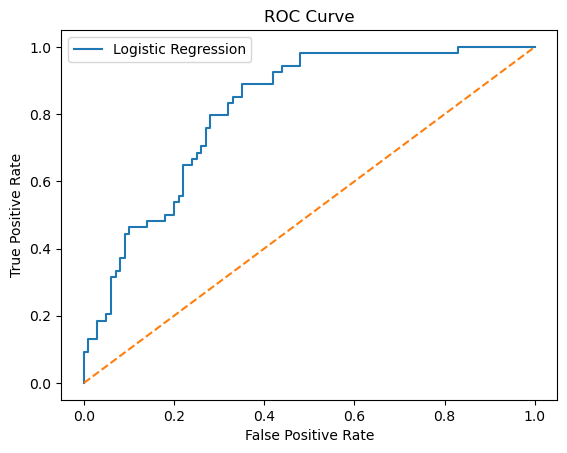

In [12]:
y_probs = log_reg.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

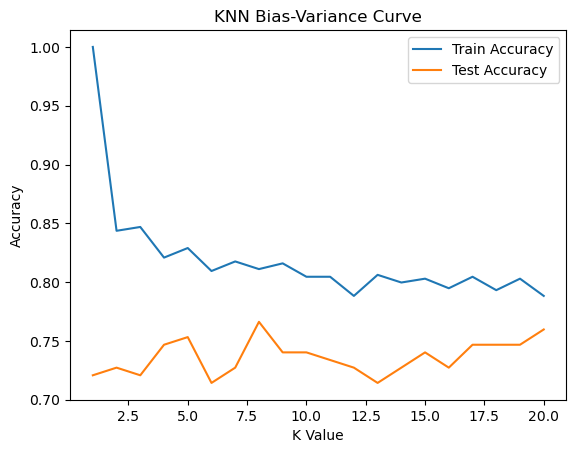

In [13]:
k_range = range(1, 21)
train_acc = []
test_acc = []

for k in k_range:
    knn = Pipeline([
        ("prep", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    
    knn.fit(X_train, y_train)
    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))

plt.plot(k_range, train_acc, label="Train Accuracy")
plt.plot(k_range, test_acc, label="Test Accuracy")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Bias-Variance Curve")
plt.legend()
plt.show()


In [14]:
svm = Pipeline([
    ("prep", preprocessor),
    ("model", SVC(kernel="rbf", C=10, gamma="scale", probability=True))
])

svm.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', SVC(C=10, probability=True))])

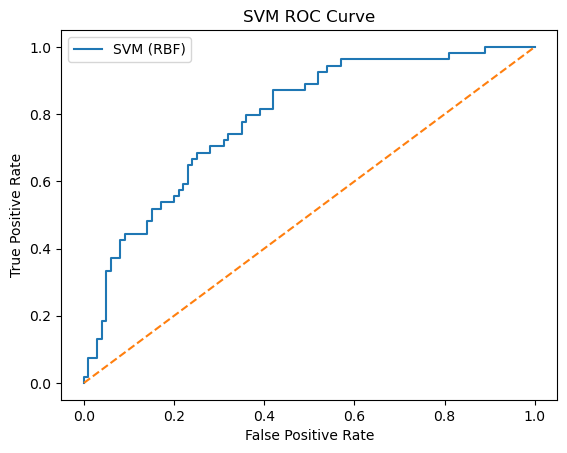

In [15]:
y_probs = svm.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr, label="SVM (RBF)")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

In [18]:
y_pred_svm = svm.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", round(svm_acc, 4))

SVM Accuracy: 0.7143


In [19]:
rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42
    ))
])

rf.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model',
                 RandomForestClassifier(max_depth=5, n_estimators=200,
                                        random_state=42))])

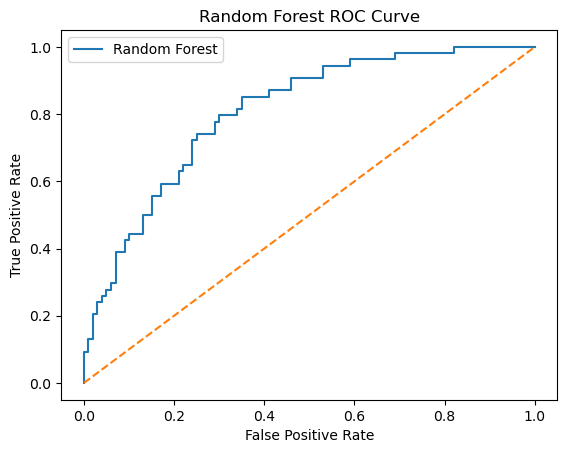

In [20]:
y_probs = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

In [21]:
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", round(rf_acc, 4))

Random Forest Accuracy: 0.7403


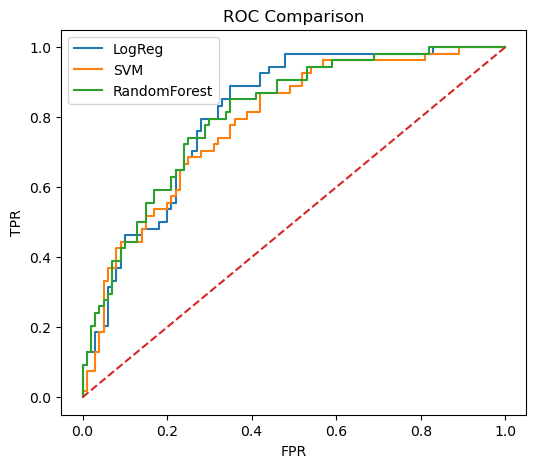

In [22]:
models = {
    "LogReg": log_reg,
    "SVM": svm,
    "RandomForest": rf
}

plt.figure(figsize=(6,5))

for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Comparison")
plt.legend()
plt.show()

In [24]:
log_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["liblinear"]
}

log_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_grid = GridSearchCV(
    log_pipeline,
    log_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

print("Best Logistic Regression Params:", log_grid.best_params_)
print("Best CV Accuracy:", round(log_grid.best_score_, 4))


Best Logistic Regression Params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV Accuracy: 0.7818


In [29]:
best_log_model = log_grid.best_estimator_
y_pred = best_log_model.predict(X_test)
y_prob = best_log_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7012987012987013
ROC-AUC: 0.8098148148148149
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



In [31]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(best_log_model, f)
